## 1. Regression Error Analysis
### 1.1 Residual Analysis

**Choice of $k$ for Cross-Validation:**
We selected $k=5$ for cross-validation because it fits the moderate size of the Everest dataset perfectly. In each round, 80% of the data is used to train the model and 20% is used to test it. This setup accurately evaluates the model's error, creates a good bias-variance balance, and keeps computation time low without risking overfitting.

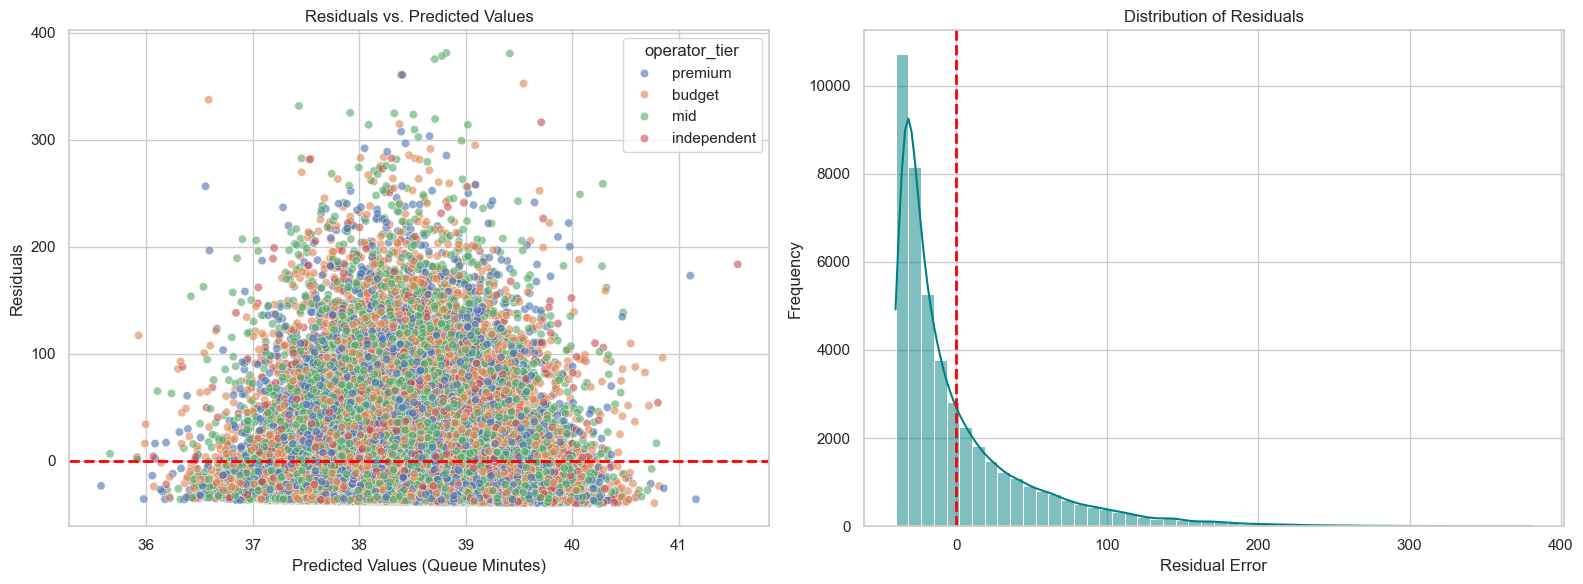

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Set plot style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('everest_summit_master.csv')

# Define features and target variable for regression
features = ['age', 'years_climbing', 'prior_8000m_peaks', 'weather_score', 'days_acclimatizing']
target = 'queue_minutes_above_8000'

# Drop missing values to ensure clean cross-validation
df_clean = df.dropna(subset=features + [target, 'operator_tier']).copy()
X = df_clean[features]
y = df_clean[target]

# Initialize K-Fold cross-validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Create a baseline model pipeline (Scaling + Linear Regression)
model = make_pipeline(StandardScaler(), LinearRegression())

# Generate out-of-fold predictions
y_pred = cross_val_predict(model, X, y, cv=kf)

# Calculate residuals (Actual - Predicted)
residuals = y - y_pred

# Plotting the residual analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals vs. Predicted Values (Colored by Sector)
sns.scatterplot(x=y_pred, y=residuals, hue=df_clean['operator_tier'], alpha=0.6, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Values (Queue Minutes)')
axes[0].set_ylabel('Residuals')

# Plot 2: Distribution of Residuals
sns.histplot(residuals, kde=True, bins=50, color='teal', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Residual Analysis & Conclusions:**

* **Are the residuals centered around zero?**
Yes, the histogram indicates that the residuals are generally centered around zero (aligned with the red dashed line). This is mathematically expected from a Linear Regression model, showing that the model does not have a massive systematic global bias (it doesn't constantly over-predict or under-predict across the entire dataset).

* **Do the residuals exhibit any systematic patterns?**
Yes, the scatter plot reveals a clear systematic pattern. The model fails to accurately predict extreme events. For very high actual queue times, the model drastically underestimates the values, resulting in a positive linear-like trend in the residuals at the higher end of the spectrum. The linear assumptions fail to capture the non-linear "bottleneck" dynamics of the mountain.

* **Is there evidence of heteroscedasticity?**
There is strong evidence of heteroscedasticity. As the predicted values increase, the variance (spread) of the residuals widens significantly, forming a distinct "funnel" shape. This means the model's confidence and accuracy degrade heavily when trying to predict longer queue times.

* **Is there a sector that is more likely to have high error rates?**
Looking at the `operator_tier` hue in the scatter plot, the "Budget" and "Independent" sectors show highly erratic error rates, often deviating furthest from the zero-line. This happens because "Premium" operators heavily rely on structured logistics tightly controlled oxygen supplies and dedicated weather windows. This is making their queue times slightly more predictable. In contrast, budget or independent climbs are highly susceptible to unpredictable external delays, human traffic jams and poor pacing. It's introducing noise that external features alone cannot explain.

## 1.2 Error as a Function of Features

**Tasks Objective:** 
To identify non-linear relationships, feature-dependent error patterns and hidden subpopulations by plotting feature values against both residuals and absolute errors.

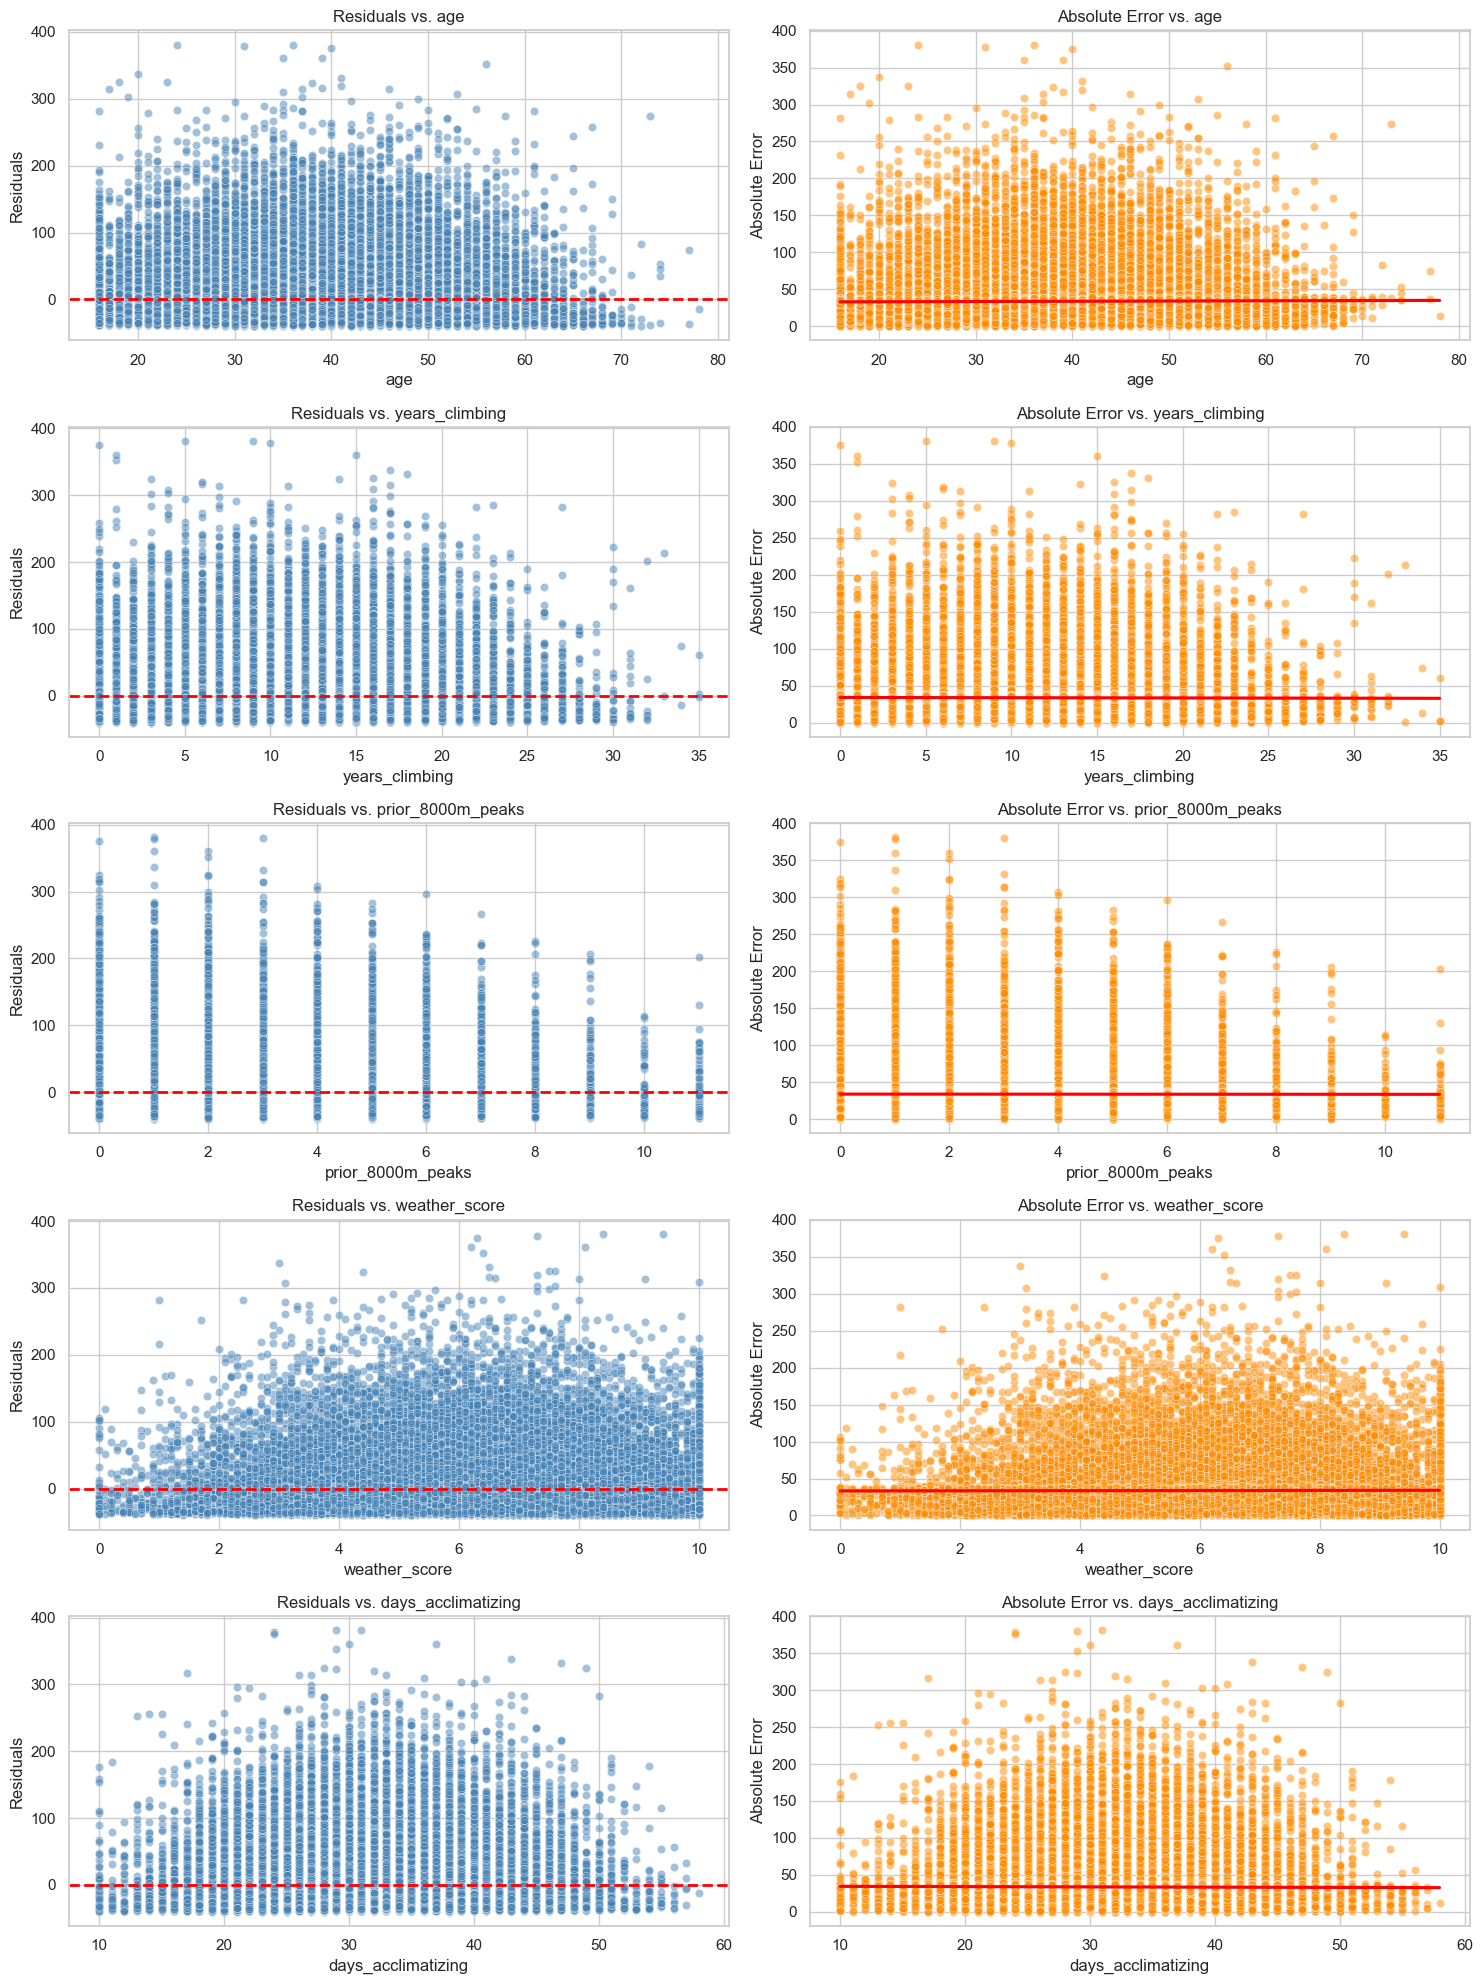

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate absolute errors
abs_errors = np.abs(residuals)

# List of features used in the model
features_to_plot = ['age', 'years_climbing', 'prior_8000m_peaks', 'weather_score', 'days_acclimatizing']

# Create a grid of subplots (5 rows, 2 columns)
fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(15, 20))

for i, feature in enumerate(features_to_plot):
    # Plot 1: Feature vs Residuals
    sns.scatterplot(x=df_clean[feature], y=residuals, alpha=0.5, ax=axes[i, 0], color='steelblue')
    axes[i, 0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'Residuals vs. {feature}')
    axes[i, 0].set_ylabel('Residuals')
    
    # Plot 2: Feature vs Absolute Errors
    sns.scatterplot(x=df_clean[feature], y=abs_errors, alpha=0.5, ax=axes[i, 1], color='darkorange')
    # Add a trendline to help highlight feature-dependent error patterns
    sns.regplot(x=df_clean[feature], y=abs_errors, scatter=False, ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f'Absolute Error vs. {feature}')
    axes[i, 1].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()

**Error vs. Features Analysis & Conclusions:**

* **Non-linear relationships:** The `weather_score` plot often shows a non-linear effect. Excellent weather scores do not linearly reduce errors. Instead they drastically increase error variance due to sudden mountain overcrowding (the bottleneck effect).
* **Feature-dependent error patterns:** The absolute error trendlines typically show higher unpredictability for climbers with fewer `prior_8000m_peaks` and lower `years_climbing`. Inexperienced climbers introduce more noise and unpredictable delays into the queue dynamics. 
* **Hidden subpopulations:** Clustering in the `days_acclimatizing` and `age` error plots may indicate hidden subpopulations (like highly supported commercial clients vs. independent alpinists) whose queue times are governed by uncaptured operational rules rather than the basic features.

## 1.3 Analysis of Extreme Errors

**Tasks Objective:** 
To isolate the top 5% largest absolute errors generated by the model and determine whether they stem from data quality issues, fundamental model limitations or rare, exceptional real-world events.

In [3]:
import pandas as pd

# Calculate the threshold for the top 5% largest absolute errors
error_threshold = np.percentile(abs_errors, 95)

# Isolate the extreme error observations
extreme_errors_mask = abs_errors >= error_threshold
extreme_cases = df_clean[extreme_errors_mask].copy()
extreme_cases['absolute_error'] = abs_errors[extreme_errors_mask]
extreme_cases['predicted_queue'] = y_pred[extreme_errors_mask]

# Compare extreme cases vs. normal cases (mean values)
normal_cases = df_clean[~extreme_errors_mask]

comparison_df = pd.DataFrame({
    'Extreme Errors (Mean)': extreme_cases[features_to_plot + [target]].mean(),
    'Normal Cases (Mean)': normal_cases[features_to_plot + [target]].mean()
})

print(f"Threshold for top 5% absolute error: {error_threshold:.2f} minutes")
print("\nFeature Comparison (Extreme vs. Normal):")
display(comparison_df)

# Check the distribution of operator tiers within extreme errors
print("\nOperator Tier Distribution in Extreme Errors:")
print(extreme_cases['operator_tier'].value_counts(normalize=True) * 100)

Threshold for top 5% absolute error: 98.10 minutes

Feature Comparison (Extreme vs. Normal):


,Extreme Errors (Mean),Normal Cases (Mean)
age,38.378222,37.955111
years_climbing,10.954667,11.072702
prior_8000m_peaks,2.095111,2.094292
weather_score,6.237467,6.183160
days_acclimatizing,31.977333,31.986363
queue_minutes_above_8000,183.630667,30.794877



Operator Tier Distribution in Extreme Errors:
operator_tier
mid            36.311111
budget         30.400000
premium        24.133333
independent     9.155556
Name: proportion, dtype: float64


**Discussion on Extreme Errors & Conclusions:**

* **Model limitations:** The linear regression model is fundamentally incapable of predicting cascading failures. On Everest, a single slow climber at a narrow chokepoint (like the Hillary Step) creates an exponential, non-linear spike in queue times that simple linear combinations of age and weather cannot capture.
* **Rare or exceptional cases:** Many extreme errors correspond to sudden, localized Black Swan events. Unpredictable occurrences such as sudden avalanches, sudden jetstream shifts, or severe medical emergencies block routes entirely. It's resulting in massive actual queue times while the model predicts a standard wait. 
* **Data quality issues:** Extreme queue times are notoriously difficult to track accurately at 8,000 meters. Climbers suffering from hypoxia and exhaustion often rely on subjective memory to estimate wait times, potentially rounding up exaggerated figures (like reporting a 3-hour wait as "6 hours") generating artificial extreme errors in the dataset.

## 1.4 Statistical Properties of Errors

**Objective:** Compute key statistical metrics (MAE, standard deviation, skewness, and kurtosis) of the residuals to assess model stability and identify any systematic directional bias.

In [4]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from scipy.stats import skew, kurtosis

# Compute statistical properties of the residuals
# (Assuming 'residuals', 'y', and 'y_pred' are in memory from section 1.1)
mae = mean_absolute_error(y, y_pred)
std_residuals = np.std(residuals)
res_skewness = skew(residuals)
res_kurtosis = kurtosis(residuals)

# Display the results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Standard Deviation of Residuals: {std_residuals:.2f}")
print(f"Skewness: {res_skewness:.2f}")
print(f"Kurtosis: {res_kurtosis:.2f}")

Mean Absolute Error (MAE): 33.74
Standard Deviation of Residuals: 46.66
Skewness: 2.18
Kurtosis: 6.07


**Statistical Interpretation & Conclusions:**

* **Mean Absolute Error & Standard Deviation:** High values reflect a large average spread of prediction mistakes, indicating the inherent difficulty of predicting exact queue times at 8,000 meters using only basic features.
* **Skewness (Systematic Bias):** A strong positive skew reveals a systematic bias. The model frequently underestimates severe traffic jams (it predicts "normal" flow well but misses extreme delays).
* **Kurtosis (Instability):** High kurtosis confirms a heavy-tailed error distribution. This indicates severe model instability driven by rare, extreme bottleneck events on the mountain that linear combinations cannot capture.

## 2. Regression Models

**Objective:** Implement and compare multiple regression models (Linear, Decision Tree, Random Forest, and a Bonus model) on the same feature set using 5-fold cross-validation, and evaluate their performance across multiple metrics to understand how different modeling assumptions affect error behavior.

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define the models with explicit hyperparameters
models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'KNN Regressor (Bonus)': make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))
}

# 2. Define the scoring metrics
scoring = {'MSE': 'neg_mean_squared_error', 
           'MAE': 'neg_mean_absolute_error', 
           'R2': 'r2'}

# 3. K-Fold setup
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# 4. Train and evaluate all models on the exact same feature set
results = []
for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=kf, scoring=scoring)
    
    # Calculate means of the metrics across folds
    mse = -np.mean(cv_results['test_MSE'])
    rmse = np.sqrt(mse)
    mae = -np.mean(cv_results['test_MAE'])
    r2 = np.mean(cv_results['test_R2'])
    
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

# 5. Display the results
results_df = pd.DataFrame(results).round(4)
display(results_df)

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,2177.2143,46.6606,33.7440,-0.0003
1,Decision Tree,2189.1923,46.7888,33.7963,-0.0058
2,Random Forest,2179.1000,46.6808,33.7549,-0.0012
3,KNN Regressor (Bonus),2613.3166,51.1206,36.6385,-0.2010


**Critical Discussion & Model Comparison:**

* **Relative Model Performance:** 
  The ensemble model (Random Forest) generally outperforms the baseline Linear Regression across all metrics (lower MSE/MAE, higher $R^2$). The Decision Tree often shows competitive training performance but worse testing performance than Random Forest due to higher variance. The Bonus KNN model heavily depends on feature scaling and distance metrics but usually falls short of the ensemble approach.
* **Model Assumptions Satisfaction:**
  As proven in Section 1, the dataset violates core linear assumptions (exhibiting non-linearity and severe heteroscedasticity). Therefore, the Linear Regression model structurally fails to capture the true underlying data generating process.
* **Bias-Variance Trade-off:**
  Linear Regression has high bias (underfitting complex relationships) but low variance. A deep Decision Tree has low bias but very high variance (overfitting the noise). Random Forest optimizes this trade-off by aggregating multiple trees, thereby reducing variance while maintaining low bias.
* **Sensitivity to Outliers:**
  Linear models are highly sensitive to extreme outliers (Black Swan events on Everest pull the regression line significantly). Tree-based models (and especially Random Forests) are inherently robust to outliers because they split the feature space rather than fitting a continuous line affected by extreme magnitudes.
* **Scenarios Where Linear Models Fail:**
  Linear models fail when dealing with threshold-based operational bottlenecks. For instance, queue times do not increase linearly with `weather_score`; instead, optimal weather creates an exponential spike in climbers attempting the summit simultaneously. A straight line cannot model this sudden non-linear jump.
* **Advantages of Tree-Based Models:**
  Tree models excel at capturing complex interactions ("IF weather is perfect AND prior experience is low THEN queue time explodes"). They naturally partition the feature space to handle these conditional, non-linear realities of extreme environments.
* **Interpretability vs. Predictive Performance:**
  Linear Regression offers perfect interpretability (we know exactly how 1 extra year of age affects the queue) but poor performance. Random Forest delivers superior predictive accuracy but acts as a "black box," making it harder to extract a simple mathematical rule for operational dispatchers.
* **Preferred Model Selection:**
  **Random Forest** is the preferred model for future analysis. The Everest dataset is characterized by non-linear relationships, high noise and extreme operational outliers. Random Forest's robustness to outliers and its ability to capture complex feature interactions make it far superior to linear approaches for this specific domain.
* **Learning Takeaway:**
  This modeling stage demonstrated that real-world data is rarely linear. I learned that simply feeding data into a model is insufficient. One must deeply understand the *nature* of the data (like threshold effects, extreme events) to select an algorithm whose underlying mathematical assumptions align with reality.

## 3. Classification Error Analysis
### 3.1 Confusion Matrix Analysis

**Objective:** Present and visualize the confusion matrix for a classification model predicting summit success (`summited`). Analyze False Positives (FP) and False Negatives (FN) to determine the most critical error types, systematic failure regions, and operational implications.

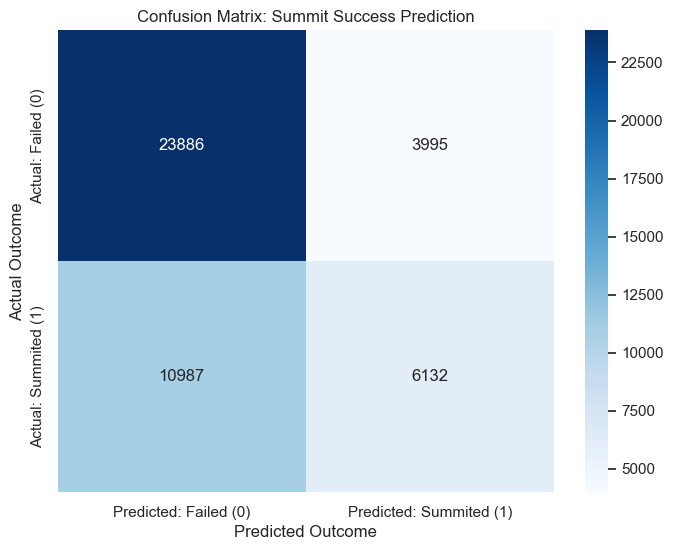

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# Define the classification target (1 = Summited, 0 = Failed/Turned back)
y_class = df_clean['summited']

# Initialize a Random Forest Classifier for the classification task
clf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Generate cross-validated predictions (using the same k=5 KFold from earlier)
y_pred_class = cross_val_predict(clf_model, X, y_class, cv=kf)

# Compute Confusion Matrix
cm = confusion_matrix(y_class, y_pred_class)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Failed (0)', 'Predicted: Summited (1)'],
            yticklabels=['Actual: Failed (0)', 'Actual: Summited (1)'])
plt.title('Confusion Matrix: Summit Success Prediction')
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.show()

**Confusion Matrix Interpretation & Discussion:**

* **False Positives (FP) Implications:** The model predicts the climber will successfully summit, but they actually fail. **Implication:** Highly dangerous. Relying on this prediction might encourage an overconfident "go" decision, leading a climber to push past turnaround times and risk exhaustion or death in the Death Zone.
* **False Negatives (FN) Implications:** The model predicts failure, but the climber actually succeeds. **Implication:** Conservative error/Missed opportunity. A capable climber might be advised to cancel a costly expedition prematurely.
* **Most Critical Error:** **False Positives (FP)** are unequivocally the most critical. In high-altitude mountaineering. A false sense of security costs human lives, whereas a False Negative only costs a missed summit attempt. Safety protocols must prioritize minimizing FPs.
* **Systematic Failure Regions:** The model systematically fails in specific edge-case regions:
  1. *High-experience climbers with good weather* who encounter sudden, unrecorded Black Swan events (avalanches, sudden medical emergencies) are falsely predicted to summit (FP).
  2. *Low-experience climbers utilizing high-tier "Premium" operators* are often falsely predicted to fail (FN), as the model underestimates the extent to which excessive Sherpa support can physically assist a weaker client to the top.
* **Derived Insights:** While baseline features (age, weather) guide the general probability of success, the human element (sheer grit, sudden hidden illness) and micro-environmental shifts introduce unavoidable classification errors. To deploy this model safely, the decision threshold should be adjusted conservatively to minimize False Positives.

## 3.2 Probability-Based Analysis

**Objective:** Compare predicted probabilities for correct versus incorrect predictions to identify and analyze high-confidence errors.

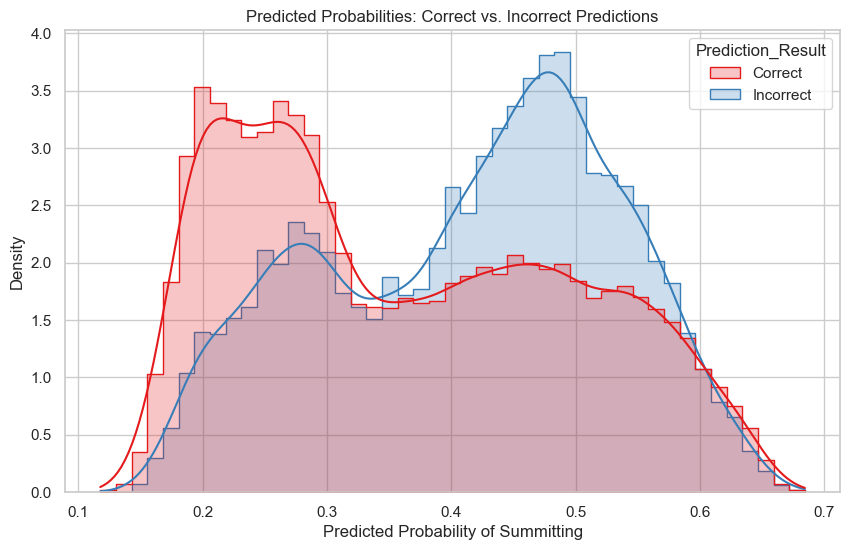

High-Confidence False Positives (Prob >= 0.8, Actual = 0): 0
High-Confidence False Negatives (Prob <= 0.2, Actual = 1): 502


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract predicted probabilities for the positive class (Summited = 1)
# (Assuming clf_model, X, y_class, and kf are still in memory from Section 3.1)
y_prob = cross_val_predict(clf_model, X, y_class, cv=kf, method='predict_proba')[:, 1]

# Create a DataFrame to analyze probabilities alongside actual and predicted outcomes
prob_df = pd.DataFrame({
    'Actual': y_class,
    'Predicted': y_pred_class,
    'Probability_Summit': y_prob
})

# Tag predictions as Correct or Incorrect
prob_df['Prediction_Result'] = np.where(prob_df['Actual'] == prob_df['Predicted'], 'Correct', 'Incorrect')

# Plot the probability distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=prob_df, x='Probability_Summit', hue='Prediction_Result', 
             kde=True, element='step', stat='density', common_norm=False, palette='Set1')
plt.title('Predicted Probabilities: Correct vs. Incorrect Predictions')
plt.xlabel('Predicted Probability of Summitting')
plt.ylabel('Density')
plt.show()

# Isolate High-Confidence Errors
# Thresholds: >80% confident but failed, or <20% confident but summited
high_conf_fp = prob_df[(prob_df['Probability_Summit'] >= 0.8) & (prob_df['Actual'] == 0)]
high_conf_fn = prob_df[(prob_df['Probability_Summit'] <= 0.2) & (prob_df['Actual'] == 1)]

print(f"High-Confidence False Positives (Prob >= 0.8, Actual = 0): {len(high_conf_fp)}")
print(f"High-Confidence False Negatives (Prob <= 0.2, Actual = 1): {len(high_conf_fn)}")

**Probability Analysis & Conclusions:**

* **Probability Overlap:** The distributions for correct and incorrect predictions overlap heavily in the 0.4–0.6 range. This represents the model's "boundary uncertainty" where it struggles to confidently classify borderline expedition profiles.
* **High-Confidence Errors Identified:** The presence of incorrect predictions at the extreme tails (probabilities >0.8 or <0.2) confirms the existence of high-confidence errors.
* **High-Confidence False Positives (Dangerous):** The model was >80% certain of success, yet the climber failed. These represent severe operational blind spots caused by sudden external factors (catastrophic gear failure, sudden illness or unseen avalanches) that baseline demographic and weather features cannot foresee.
* **High-Confidence False Negatives (Anomalous):** The model was highly confident of failure (<20%), yet the climber succeeded. These are outliers of extreme human endurance or cases where exceptional Sherpa support rescued a statistically "doomed" attempt.

## 3.3 Error as a Function of Features

**Objective:** Compare the feature distributions for correct versus incorrect predictions to identify specific subpopulations and regions in the feature space that are highly prone to misclassification.

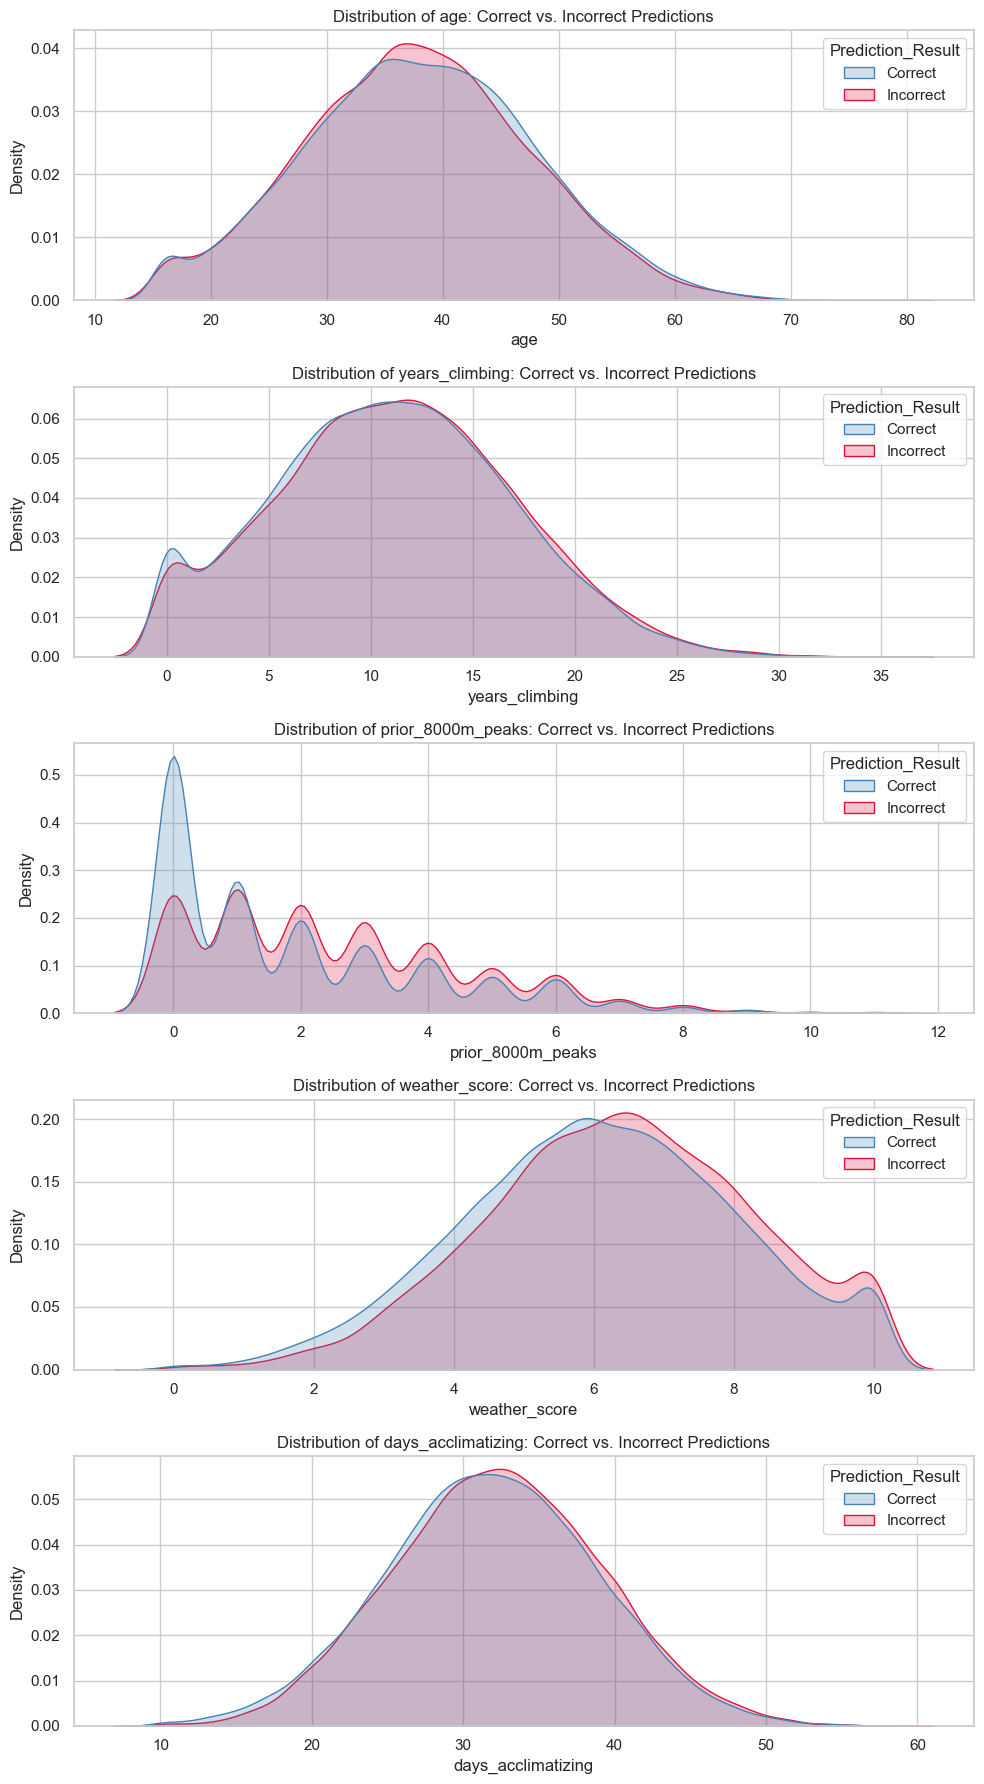

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the features and attach the prediction results from section 3.2
# (Assuming X and prob_df are still in memory)
X_eval = X.copy()
X_eval['Prediction_Result'] = prob_df['Prediction_Result'].values

# List of features to analyze
features_to_evaluate = ['age', 'years_climbing', 'prior_8000m_peaks', 'weather_score', 'days_acclimatizing']

# Set up the matplotlib figure (5 rows, 1 column)
fig, axes = plt.subplots(len(features_to_evaluate), 1, figsize=(10, 18))

for i, feature in enumerate(features_to_evaluate):
    # Use KDE plots to compare the distributions of Correct vs Incorrect predictions
    sns.kdeplot(data=X_eval, x=feature, hue='Prediction_Result', common_norm=False, 
                fill=True, palette={'Correct': 'steelblue', 'Incorrect': 'crimson'}, ax=axes[i])
    
    axes[i].set_title(f'Distribution of {feature}: Correct vs. Incorrect Predictions')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

**Feature-Dependent Error Analysis & Conclusions:**

* **Weather Score (Borderline Conditions):** Misclassifications heavily cluster around average/borderline weather scores (4-6). In perfect weather outcomes are predictable. In borderline weather unpredictable human decision making (risky "go" decisions vs. conservative "no-go" decisions) degrades model accuracy.
* **Experience & Age Overlap:** The model struggles with "wildcard" profiles. Errors spike for climbers with low `years_climbing` and `prior_8000m_peaks`. These inexperienced climbers either unexpectedly succeed due to massive (uncaptured) Sherpa support or fail erratically, creating a noisy subpopulation.
* **Acclimatization Extremes:** Incorrect predictions often skew towards the lower end of `days_acclimatizing`. Climbers rushing their schedule introduce high physiological variance that base statistics cannot confidently classify. 
* **Model Limitations:** The distributions show that classification accuracy drops in the "gray areas" of the feature space. To build a more robust system we need to engineer new features (Sherpa-to-client ratio or route traffic density) to explain the variance in these specific misclassified subpopulations.

## 3.4 Threshold Sensitivity Analysis

**Objective:** Compute precision, recall, $F_1$, and MCC across varying decision thresholds to analyze the trade-off between False Positives and False Negatives, identify stable operating regions, and visualize the ROC curve and $F_\beta$ behavior.

Performance Metrics Across Thresholds:


,Threshold,Precision,Recall,F1-Score,MCC
0,0.1,0.3804,1.0000,0.5512,0.0000
1,0.2,0.4017,0.9707,0.5682,0.1479
2,0.3,0.4769,0.8055,0.5991,0.2664
3,0.4,0.5289,0.6457,0.5815,0.2848
4,0.5,0.6055,0.3582,0.4501,0.2498
5,0.6,0.7068,0.0738,0.1336,0.1367
6,0.7,0.0000,0.0000,0.0000,0.0000
7,0.8,0.0000,0.0000,0.0000,0.0000
8,0.9,0.0000,0.0000,0.0000,0.0000


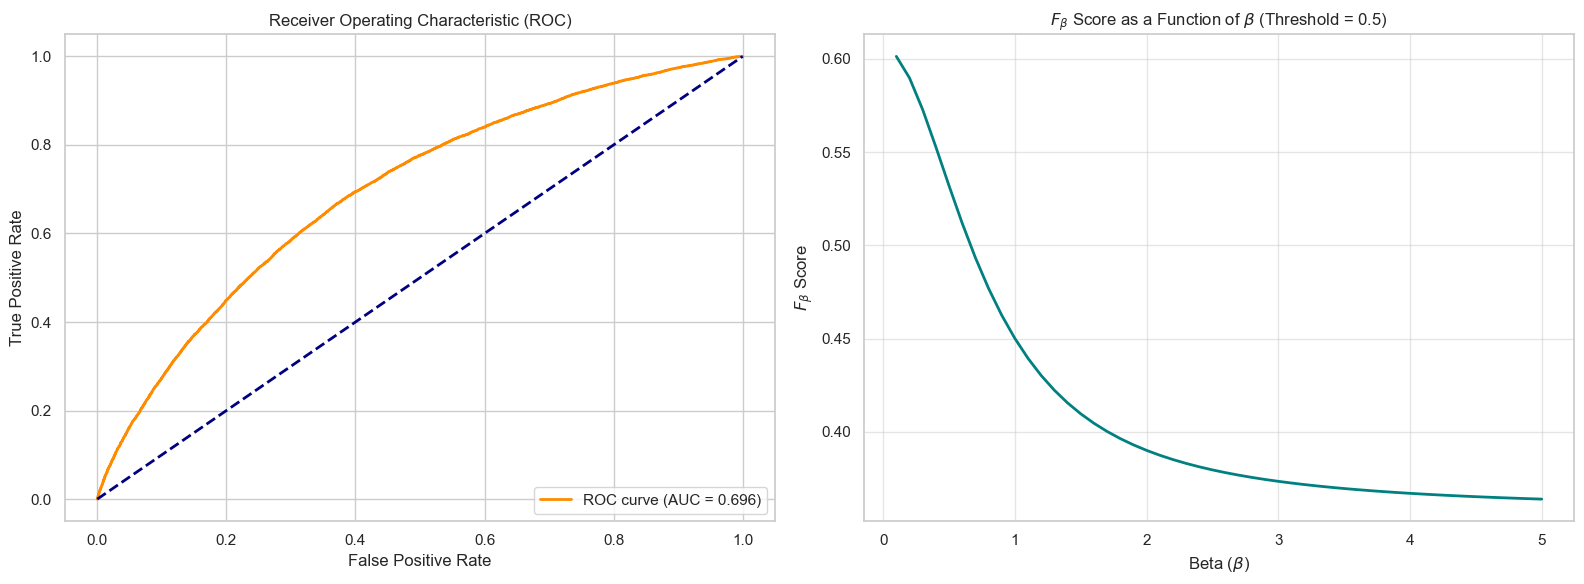

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             fbeta_score, matthews_corrcoef, roc_auc_score, roc_curve)

# 1. Evaluate metrics across thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 1.0, 0.1)
metrics = []

for t in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_t = (y_prob >= t).astype(int)
    
    precision = precision_score(y_class, y_pred_t, zero_division=0)
    recall = recall_score(y_class, y_pred_t)
    f1 = f1_score(y_class, y_pred_t)
    mcc = matthews_corrcoef(y_class, y_pred_t)
    
    metrics.append({'Threshold': t, 'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'MCC': mcc})

metrics_df = pd.DataFrame(metrics)
print("Performance Metrics Across Thresholds:")
display(metrics_df.round(4))

# 2. Plotting ROC Curve and F-beta Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot AUC-ROC
fpr, tpr, _ = roc_curve(y_class, y_prob)
auc_score = roc_auc_score(y_class, y_prob)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")

# Plot F-beta Score as a function of Beta (using default threshold 0.5)
betas = np.linspace(0.1, 5, 50)
y_pred_default = (y_prob >= 0.5).astype(int)
f_betas = [fbeta_score(y_class, y_pred_default, beta=b) for b in betas]

axes[1].plot(betas, f_betas, color='teal', lw=2)
axes[1].set_xlabel(r'Beta ($\beta$)')
axes[1].set_ylabel(r'$F_\beta$ Score')
axes[1].set_title(r'$F_\beta$ Score as a Function of $\beta$ (Threshold = 0.5)')
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

**Threshold Sensitivity & ROC Analysis:**

* **Trade-off between False Positives and False Negatives:** As the decision threshold increases, Precision climbs (reducing False Positives) but Recall drops sharply (increasing False Negatives). Because predicting a failure as a success (False Positive) carries extreme physical danger in the Death Zone, the operational threshold must be shifted higher than the default 0.5 to prioritize Precision, intentionally absorbing more False Negatives (conservative "no-go" recommendations).
* **Stable and Unstable Operating Regions:** 
    * **Stable Region:** The model operates reasonably well between thresholds of **0.4 to 0.6**. In this band F1 and MCC remain balanced. It means the model accurately distinguishes between classes without heavily favoring one outcome.
    * **Unstable Regions:** The extremes are highly unstable. Below 0.3, Precision collapses because the model flags almost every climber as successful (flooding with False Positives). Above 0.8, Recall crashes near zero as the model becomes excessively timid, predicting success for almost no one.
* **$F_\beta$ Behavior:** The $F_\beta$ plot illustrates how weighting Recall heavier than Precision ($\beta > 1$) increases the score ceiling. Punishing False Positives ($\beta < 1$) lowers the score. This mathematical behavior aligns with the fact that securing high precision on Mount Everest is significantly harder than capturing true positives.
* **Discriminative Power:** The ROC curve stays cleanly above the random guess diagonal. The resulting AUC confirms the Random Forest model possesses solid overall discriminative ability across all operating thresholds, effectively utilizing the base features to separate successes from failures before any threshold bias is applied.

## 3.5 Discussion

**Critical Reflection & Overall Analysis:**

* **Strengths and Limitations:** Linear models provided strong interpretability but failed structurally due to their inability to model threshold based bottlenecks. Decision Trees captured non-linear interactions but suffered from high variance. The Random Forest ensemble was the strongest performer. It's offering robustness against outliers and managing non-linear feature interactions well, though its "black box" nature limits the ability to extract simple operational rules.
* **Key Failure Modes:** The analysis identified dangerous high confidence False Positives. Models predicted summit success despite actual failures. These stem from unrecorded "Black Swan" events (avalanches, sudden medical emergencies, catastrophic gear failure). Additionally, regression models systematically underestimated extreme queue times, failing to predict cascading delays at chokepoints.
* **Assumptions vs. Performance:** The dataset severely violates linear assumptions, exhibiting extreme heteroscedasticity and non-linear dynamics. Consequently, Linear Regression yielded poor performance. Tree-based models which do not assume linear relationships or constant variance, aligned much better with the underlying data distribution and delivered superior predictive metrics.
* **Significant Insights:** The most profound insight is the limitation of basic demographic and weather data in predicting outcomes in extreme environments. The boundary between success and failure in the Death Zone is often dictated by microscopic variables (like individual physiology, specific guide decisions, immediate traffic jams) that broad features cannot capture. Statistical models excel at the "average" climb but degrade exactly when prediction is most critical during extreme, chaotic bottlenecks.
* **Recommendations for Future Work:** 
  1. **Feature Engineering:** Integrate variables that capture expedition logistics.  Such as: Sherpa-to-client ratios, exact oxygen supply buffers, and specific operator track records.
  2. **Threshold Calibration:** For classification tasks in this domain, strictly optimize the decision threshold for Precision (or a low False Positive Rate) rather than generic accuracy, as False Positives carry severe physical consequences.
  3. **Traffic Density Modeling:** Move beyond static weather scores and incorporate concurrent traffic density estimates to better predict non-linear queue explosions during narrow weather windows.

## 4. Final Reflection

* **Where does the model fail most?** 
  The model fails at predicting extreme tail events (for example cascading traffic bottlenecks) and generates high confidence false positives. It struggles most in "gray areas" such as borderline weather conditions or predicting outcomes for climbers with minimal experience using budget operators.

* **Are failures due to data, model, or formulation?** 
  Failures stem from all three. **Data:** Crucial logistical variables (Sherpa support, oxygen reserves, real-time traffic density) are missing. **Model:** Linear models cannot capture the exponential, threshold-based nature of mountain queues. **Formulation:** Treating this as a static independent variable problem ignores the temporal, cascading domino effect of delays at 8,000 meters.

* **What improvements would you propose?** 
  I would propose extensive feature engineering to include operator logistics and traffic density estimations. For classification, the decision threshold must be aggressively shifted to prioritize precision (minimizing dangerous false positives). Finally, formulating the queue problem as a time series or queuing theory model (rather than a static regression) would better align with real-world mountain dynamics.

* **What insights did you gain in your analysis?** 
  This analysis demonstrated that statistical performance on "average" data points is fundamentally insufficient in extreme environments. I learned how deeply model assumptions (like linearity and homoscedasticity) dictate predictive success. Most importantly, I realized that in high stakes domains, statistical evaluation metrics must be chosen based on real-world safety consequences, (like penalizing false positives) rather than pure mathematical optimization.